[![Open In Colab](https://colab.research.google.com/assets/colab-badge.svg)](https://colab.research.google.com/github/danpele/MFM/blob/main/notebooks/EN/chapter19_lecture_notebook.ipynb)

# Modelling Financial Markets — Chapter 19: Review and Project Presentations

- Integrated case study on the BET index (Bucharest Exchange Trading, the main index of the Bucharest Stock Exchange): stylised facts → GARCH(1,1)-t → VaR 1% → backtesting.
- Loss $L = -r$, daily log return in %; VaR is a positive number; the level is the tail probability (VaR 1%).

> **Working in Google Colab? Save your own copy first.**
> The Colab link opens a temporary copy: when you close the tab or the session times out, your changes are lost.
> Use **File → Save a copy in Drive** (it goes to the *Colab Notebooks* folder of your ASE Google Drive) and work in that copy.
> For the team project, **File → Save a copy in GitHub** puts the notebook directly in your team's repository.
> Files you create while the notebook runs (CSV, charts) are also temporary: set `SAVE_TO_DRIVE = True` in the next cell to keep them.

In [ ]:
# Optional (Colab only): keep the files you create in Google Drive
SAVE_TO_DRIVE = False   # set to True, run this cell and allow access to your Drive

import os
OUT_DIR = '.'
if SAVE_TO_DRIVE:
    from google.colab import drive
    drive.mount('/content/drive')
    OUT_DIR = '/content/drive/MyDrive/MFM/Chapter_19'
    os.makedirs(OUT_DIR, exist_ok=True)
print('Save your outputs to:', os.path.abspath(OUT_DIR))


In [1]:
# On Colab, install arch first: !pip install arch
import os
import re
import json
import urllib.request
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from scipy import stats, optimize
from arch import arch_model
import warnings
warnings.filterwarnings('ignore')

## Data

In [2]:
REPO_RAW = 'https://raw.githubusercontent.com/danpele/MFM/main/data/market/'
# read the course data (local copy when run inside the course repository)
MARKET_DIR = next((os.path.join(d, 'data', 'market') for d in ('.', '..', '../..', '../../..')
                   if os.path.isdir(os.path.join(d, 'data', 'market'))), '')
END = '2026-09-18'

# name -> (symbol, label, type, start date)
MARKETS = {
    'sp500':  ('GSPC.INDX',    'S&P 500',                  'index',  '2000-01-01'),
    'bet':    ('BET',          'BET',                      'index',  '2000-01-01'),
    'btc':    ('BTC-USD.CC',   'Bitcoin',                  'crypto', '2014-09-17'),
    'eurron': ('REF:EUR',      'EUR/RON (reference rate)', 'fx',     '2005-07-01'),
    'gold':   ('XAUUSD.FOREX', 'Gold (XAU/USD)',           'fx',     '2000-01-01'),
}
# assets for portfolios (prices aligned on common days)
ASSETS = {
    'SPY': ('SPY.US', 'adjusted_close'), 'TLT': ('TLT.US', 'adjusted_close'), 'GLD': ('GLD.US', 'adjusted_close'),
    'BTC': ('BTC-USD.CC', 'close'),
    'TLV': ('TLV.RO', 'adjusted_close'), 'SNP': ('SNP.RO', 'adjusted_close'), 'BRD': ('BRD.RO', 'adjusted_close'),
    'TGN': ('TGN.RO', 'adjusted_close'), 'SNG': ('SNG.RO', 'adjusted_close'), 'SNN': ('SNN.RO', 'adjusted_close'),
    'EL': ('EL.RO', 'adjusted_close'), 'FP': ('FP.RO', 'adjusted_close'), 'TEL': ('TEL.RO', 'adjusted_close'),
    'WIG20': ('WIG20.INDX', 'close'),
}
LABELS = {k: v[1] for k, v in MARKETS.items()}

_CACHE = {}


def read_market(symbol):
    """Read one daily price series of the course data (local copy or the course GitHub repository)."""
    fname = f'{symbol}.csv'
    path = os.path.join(MARKET_DIR, fname)
    src = path if os.path.exists(path) else REPO_RAW + fname
    return pd.read_csv(src, index_col='date', parse_dates=True).sort_index()


def read_reference_rate(currency='EUR', start='2005-07-01', end=END):
    """Official RON reference rate (annual BNR XML archives)."""
    key = (currency, start, end)
    if key in _CACHE:
        return _CACHE[key]
    rows = []
    for y in range(int(start[:4]), int(end[:4]) + 1):
        url = f'https://curs.bnr.ro/files/xml/years/nbrfxrates{y}.xml'
        xml = urllib.request.urlopen(urllib.request.Request(url, headers={'User-Agent': 'Mozilla'}),
                                     timeout=60).read().decode()
        for d, body in re.findall(r'<Cube date="([\d-]+)">(.*?)</Cube>', xml, re.S):
            m = re.search(rf'<Rate currency="{currency}">([\d.]+)</Rate>', body)
            if m:
                rows.append((d, float(m.group(1))))
    s = pd.DataFrame(rows, columns=['date', 'close']).drop_duplicates('date').set_index('date')['close']
    s.index = pd.to_datetime(s.index)
    _CACHE[key] = s.sort_index().loc[start:end]
    return _CACHE[key]


def drop_duplicate_records(df):
    """Remove duplicate records: rows identical (open, high, low, close, volume) to the previous row."""
    cols = [c for c in ('open', 'high', 'low', 'close', 'volume') if c in df.columns]
    return df[~(df[cols] == df[cols].shift()).all(axis=1)]


def load_close(name, start=None, end=END):
    """Daily price, cleaned with the conventions of the chapter."""
    symbol, _, kind, start0 = MARKETS[name]
    start = start or start0
    if symbol.startswith('REF:'):
        return read_reference_rate(symbol.split(':')[1], start=start, end=end).rename(name)
    df = read_market(symbol).loc[start:end]
    if kind != 'crypto':
        df = df[df.index.dayofweek < 5]       # no weekend quotes
    if kind == 'index':
        df = drop_duplicate_records(df)       # no duplicate records
    s = df['close']
    s = s[s > 0].dropna()
    return s.rename(name)


def log_returns(name, start=None, end=END):
    """Log returns on the own calendar of the series."""
    return np.log(load_close(name, start, end)).diff().dropna().rename(name)


def periods_per_year(r):
    """Real frequency: average number of observations per calendar year."""
    return len(r) / ((r.index[-1] - r.index[0]).days / 365.25)


def asset_price(key, end=END):
    symbol, col = ASSETS[key]
    df = read_market(symbol).loc[:end]
    if key != 'BTC':
        df = df[df.index.dayofweek < 5]       # no weekend quotes
    if symbol.endswith('.INDX'):
        df = drop_duplicate_records(df)       # no duplicate records
    s = df[col]
    s = s[s > 0].dropna()
    return s.rename(key)


def joint_returns(keys, start=None, end=END):
    """Log returns for several assets: PRICES aligned on common days first, then returns."""
    p = pd.concat([asset_price(k, end) for k in keys], axis=1, join='inner').dropna()
    if start:
        p = p.loc[start:]
    return np.log(p).diff().dropna()

## Inference functions

- Hill tail index with confidence intervals (CI); profile likelihood for the persistence of GARCH (generalised autoregressive conditional heteroskedasticity); the dynamic quantile (DQ) test; the FZ0 loss (Fissler–Ziegel, zero-homogeneous) with Diebold–Mariano (DM) tests and the model confidence set (MCS); a comparative backtest of expected shortfall (ES); the power of the Kupiec test; the sup-Wald break test.

In [3]:
# =============================================================================
# 1. HILL TAIL INDEX
# =============================================================================
def hill(losses, k):
    """Hill estimator of the tail index from the k largest (positive) losses."""
    x = np.sort(np.asarray(losses)[np.asarray(losses) > 0])[::-1]
    return 1.0 / np.mean(np.log(x[:k]) - np.log(x[k]))


def hill_k(r, share=0.05):
    """k = 5% of the loss days (the same rule as in Chapter 16)."""
    return int(round(share * np.sum(-np.asarray(r) > 0)))


def hill_ci(r, share=0.05, B=999, block=20, seed=0):
    """Hill on losses, asymptotic i.i.d. CI alpha(1 +/- 1.96/sqrt(k)) and moving-block bootstrap CI."""
    L = -np.asarray(r)
    k = hill_k(r, share)
    a = hill(L, k)
    rng = np.random.default_rng(seed)
    T = len(L)
    nb = int(np.ceil(T / block))
    bs = np.array([hill(L[(rng.integers(0, T - block + 1, nb)[:, None] + np.arange(block)).ravel()[:T]], k)
                   for _ in range(B)])
    return dict(alpha=a, k=k, se_iid=a / np.sqrt(k), lo_iid=a - 1.96 * a / np.sqrt(k), hi_iid=a + 1.96 * a / np.sqrt(k),
                lo=np.percentile(bs, 2.5), hi=np.percentile(bs, 97.5), se_boot=bs.std(ddof=1), draws=bs)


# =============================================================================
# 2. GARCH(1,1)-t: PROFILE-LIKELIHOOD CI FOR PERSISTENCE
# =============================================================================
def garch_t_nll(theta, r):
    """-log L for GARCH(1,1) with standardised Student-t innovations; theta = (mu, omega, alpha, beta, nu)."""
    mu, om, a, b, nu = theta
    if om <= 0 or a < 0 or b < 0 or a + b > 1 or nu <= 2.05:        # a + b = 1 (IGARCH) is allowed
        return 1e10
    e = r - mu
    T = len(e)
    s2 = np.empty(T)
    s2[0] = np.var(e)
    for t in range(1, T):
        s2[t] = om + a * e[t - 1] ** 2 + b * s2[t - 1]
    c = (stats.t.logpdf(e / np.sqrt(s2 * (nu - 2) / nu), nu) - 0.5 * np.log(s2 * (nu - 2) / nu))
    return -np.sum(c)


def profile_pers(r, grid, x0):
    """Maximum likelihood with the persistence fixed at p = alpha + beta (reparametrised alpha = p*s, beta = p*(1-s))."""
    r = np.asarray(r)
    out = []
    for p in grid:
        def f(th):
            mu, om, s, nu = th
            if not 0 < s < 1:
                return 1e10
            return garch_t_nll((mu, om, p * s, p * (1 - s), nu), r)
        best = optimize.minimize(f, x0, method='Nelder-Mead', options={'xatol': 1e-6, 'fatol': 1e-3, 'maxiter': 4000})
        out.append(-best.fun)
        x0 = best.x
    return np.array(out)


def profile_ci(r, res):
    """95% profile-likelihood CI for p = alpha + beta, on the grid 0.960-0.9999 and at p = 1 (IGARCH).
    Interior points p < 1: 2(l_max - l(p)) <= 3.84 (chi2(1)); p = 1 is on the boundary of the space p <= 1, where
    the LR statistic has the distribution 0.5 chi2(0) + 0.5 chi2(1) (Andrews, 1999): p = 1 is included if LR <= 2.71."""
    p = res.params
    pers = p['alpha[1]'] + p['beta[1]']
    lmax = -garch_t_nll((p['mu'], p['omega'], p['alpha[1]'], p['beta[1]'], p['nu']), np.asarray(r))
    x0 = np.array([p['mu'], p['omega'], p['alpha[1]'] / pers, p['nu']])
    grid = np.unique(np.concatenate([np.linspace(0.960, 0.998, 39), [0.999, 0.9995, 0.9999, 1.0, pers]]))
    lp = profile_pers(r, grid, x0)
    lr = 2 * (max(lmax, lp.max()) - lp)
    crit = np.where(grid < 1, stats.chi2.ppf(0.95, 1), stats.chi2.ppf(0.90, 1))
    ok = grid[lr <= crit]
    lr1 = float(lr[grid == 1.0][0])
    return dict(pers=pers, lmax=lmax, lo=ok.min(), hi=ok.max(), grid=list(grid), lr=list(lr),
                hl_lo=np.log(0.5) / np.log(ok.min()), hl_hi=(np.inf if ok.max() >= 1 else np.log(0.5) / np.log(ok.max())),
                lr_one=lr1, p_one=float(0.5 * stats.chi2.sf(lr1, 1)), cv_one=float(stats.chi2.ppf(0.90, 1)),
                hi_at_edge=bool(ok.max() >= 1.0))


# =============================================================================
# 3. TESTS FOR RISK FORECASTS
# =============================================================================
def dq_test(L, var, a=0.01, lags=4):
    """Dynamic Quantile (Engle & Manganelli, 2004): Hit_t - a on a constant, lagged breaches and VaR_t; DQ ~ chi2(lags+2)."""
    hit = (np.asarray(L) > np.asarray(var)).astype(float) - a
    X = [np.ones(len(hit))] + [np.roll(hit, l) for l in range(1, lags + 1)] + [np.asarray(var)]
    X = np.column_stack(X)[lags:]
    y = hit[lags:]
    b = np.linalg.lstsq(X, y, rcond=None)[0]
    dq = b @ X.T @ X @ b / (a * (1 - a))
    return dict(DQ=dq, df=X.shape[1], p=stats.chi2.sf(dq, X.shape[1]))


def fz0(r, var, es, a):
    """FZ0 score (Patton, Ziegel & Chen, 2019) for v = -VaR, e = -ES (negative quantiles), return r."""
    v, e, y = -np.asarray(var), -np.asarray(es), np.asarray(r)
    return -((y <= v) * (v - y)) / (a * e) + v / e + np.log(-e) - 1


def nw_var(d, lags=None):
    d = np.asarray(d) - np.mean(d)
    T = len(d)
    lags = int(np.floor(4 * (T / 100) ** (2 / 9))) if lags is None else lags
    v = d @ d / T
    for l in range(1, lags + 1):
        v += 2 * (1 - l / (lags + 1)) * (d[l:] @ d[:-l]) / T
    return v, lags


def dm_test(l1, l2):
    """Diebold-Mariano: d = l1 - l2; t = mean(d)/sqrt(HAC var/T); d < 0 => model 1 is better."""
    d = np.asarray(l1) - np.asarray(l2)
    v, lags = nw_var(d)
    t = d.mean() / np.sqrt(v / len(d))
    return dict(mean=d.mean(), t=t, p=2 * stats.norm.sf(abs(t)), lags=lags)


def mcs(losses, B=999, block=20, alpha=0.10, seed=0):
    """Model confidence set (Hansen, Lunde & Nason, 2011), T_max statistic, moving-block bootstrap.
    losses: DataFrame T x m. Returns the MCS p-value of each model."""
    rng = np.random.default_rng(seed)
    L = losses.values
    T, m = L.shape
    nb = int(np.ceil(T / block))
    idx = [(rng.integers(0, T - block + 1, nb)[:, None] + np.arange(block)).ravel()[:T] for _ in range(B)]
    alive = list(range(m))
    pvals = {}
    pmax = 0.0
    while len(alive) > 1:
        Lm = L[:, alive]
        dbar = Lm.mean(0) - Lm.mean()                       # d_i. = L_i - mean of the remaining models
        boot = np.array([Lm[ix].mean(0) - Lm[ix].mean() for ix in idx])
        se = np.sqrt(((boot - dbar) ** 2).mean(0))
        t = dbar / se
        tmax = t.max()
        tb = ((boot - dbar) / se).max(1)
        p = float((tb >= tmax).mean())
        pmax = max(pmax, p)
        worst = alive[int(np.argmax(t))]
        pvals[losses.columns[worst]] = pmax
        alive.remove(worst)
    pvals[losses.columns[alive[0]]] = 1.0
    return {k: pvals[k] for k in losses.columns}, [c for c in losses.columns if pvals[c] >= alpha]


def comparative_backtest(s_int, s_std, level=0.05):
    """Comparative backtest (Nolde & Ziegel, 2017) with FZ0 scores: d = S(internal) - S(standard).
    Red: H0- rejected, 'internal at least as good' (d > 0 significant);
    green: H0+ rejected, 'internal at most as good' (d < 0 significant); otherwise yellow."""
    t = dm_test(s_int, s_std)['t']
    z = stats.norm.ppf(1 - level)
    zone = 'red' if t > z else ('green' if t < -z else 'yellow')
    return dict(t=t, zone=zone)


def holm(p):
    """Holm-adjusted p-values (FWER)."""
    p = np.asarray(p, float)
    o = np.argsort(p)
    m = len(p)
    adj = np.minimum(np.maximum.accumulate((m - np.arange(m)) * p[o]), 1)
    out = np.empty(m)
    out[o] = adj
    return out


def bh(p, q=0.05):
    """Benjamini-Hochberg: mask of rejections at FDR q."""
    p = np.asarray(p, float)
    m = len(p)
    o = np.argsort(p)
    ok = p[o] <= q * np.arange(1, m + 1) / m
    k = np.max(np.nonzero(ok)[0]) + 1 if ok.any() else 0
    rej = np.zeros(m, bool)
    rej[o[:k]] = True
    return rej


# =============================================================================
# 4. POWER OF THE KUPIEC TEST
# =============================================================================
def kupiec_region(T, p0=0.01, level=0.05):
    """Breach counts x for which LR_uc rejects at the given level."""
    xs = np.arange(0, T + 1)
    ph = xs / T
    with np.errstate(divide='ignore', invalid='ignore'):
        ll1 = np.where(xs > 0, xs * np.log(np.where(ph > 0, ph, 1)), 0) + \
            np.where(xs < T, (T - xs) * np.log(np.where(ph < 1, 1 - ph, 1)), 0)
    ll0 = xs * np.log(p0) + (T - xs) * np.log(1 - p0)
    lr = -2 * (ll0 - ll1)
    return xs[lr > stats.chi2.ppf(1 - level, 1)]


def kupiec_power(T, p1, p0=0.01, level=0.05):
    rej = kupiec_region(T, p0, level)
    return float(stats.binom.pmf(rej, T, p1).sum()), rej


def kupiec_mde(T, p0=0.01, power=0.80, level=0.05):
    """Smallest true rate > p0 detected with the required power."""
    for p1 in np.arange(p0 + 0.0005, 0.2, 0.0005):
        if kupiec_power(T, p1, p0, level)[0] >= power:
            return float(p1)
    return np.nan


# =============================================================================
# 5. BREAK AT AN UNKNOWN DATE
# =============================================================================
def sup_wald_break(y, trim=0.15, nsim=2000, seed=0, hac=True):
    """sup-Wald test (Andrews, 1993) for a break in the mean of y at an unknown date, HAC errors;
    p-value by simulating the limit sup_pi B(pi)^2/(pi(1-pi)) (Brownian bridge)."""
    y = np.asarray(y, float)
    T = len(y)
    lo, hi = int(np.floor(trim * T)), int(np.ceil((1 - trim) * T))
    best = (-np.inf, None)
    v, _ = nw_var(y - y.mean()) if hac else (np.var(y), 0)
    cs = np.cumsum(y)
    ybar = y.mean()
    for k in range(lo, hi):
        m1, m2 = cs[k - 1] / k, (cs[-1] - cs[k - 1]) / (T - k)
        w = (m2 - m1) ** 2 / (v * (1 / k + 1 / (T - k)))
        if w > best[0]:
            best = (w, k)
    rng = np.random.default_rng(seed)
    n = 2000
    grid = np.arange(int(trim * n), int((1 - trim) * n))
    sims = []
    for _ in range(nsim):
        W = np.cumsum(rng.standard_normal(n)) / np.sqrt(n)
        pi = grid / n
        Bb = W[grid - 1] - pi * W[-1]
        sims.append(np.max(Bb ** 2 / (pi * (1 - pi))))
    sims = np.array(sims)
    return dict(stat=best[0], k=best[1], p=float((sims >= best[0]).mean()), cv5=float(np.percentile(sims, 95)))


# =============================================================================
# 6. FORMAL EVALUATION OF THE FOUR MODELS (case study)
# =============================================================================
def formal_eval(fc, models=('HS', 'Normal', 'GARCH-t', 'FHS'), a=0.01, a_es=0.025, standard='HS'):
    """DQ at VaR 1%; FZ0 at level 2.5% for the pair (VaR 2.5%, ES 2.5%); pairwise DM; MCS; comparative backtest."""
    out = {'dq': {}, 'fz0': {}, 'dm': {}, 'cb': {}}
    S = {}
    for m in models:
        out['dq'][m] = dq_test(fc['L'], fc[m], a)
        S[m] = fz0(fc['r'], fc[m + '_V25'], fc[m + '_ES'], a_es)
        out['fz0'][m] = float(np.mean(S[m]))
    for i, m1 in enumerate(models):
        for m2 in models[i + 1:]:
            out['dm'][f'{m1}|{m2}'] = dm_test(S[m1], S[m2])
    p, keep = mcs(pd.DataFrame(S))
    out['mcs_p'], out['mcs_set'] = p, keep
    for m in models:
        if m != standard:
            out['cb'][m] = comparative_backtest(S[m], S[standard])
    out['T'] = len(fc)
    return out

## Case-study functions

- Stylised facts, GARCH(1,1)-t (Student-t innovations), rolling one-day value-at-risk (VaR) 1% and ES 2.5% from four models: historical simulation (HS), the Normal distribution, GARCH-t and filtered historical simulation (FHS); Kupiec and Christoffersen tests; Basel traffic-light zones.

In [4]:
ALPHA = 0.01          # VaR 1%
ALPHA_ES = 0.025      # ES 2.5%
WINDOW = 1000         # days in the estimation window
REFIT = 21            # GARCH re-estimated every 21 days
HS_WINDOW = 500       # window for HS and for the Normal distribution
MODELS = ['HS', 'Normal', 'GARCH-t', 'FHS']


# -----------------------------------------------------------------------------
# 1. STYLISED FACTS
# -----------------------------------------------------------------------------
def ljung_box(x, m=10):
    """Q(m) = T(T+2) sum rho_k^2/(T-k) and its chi2(m) p-value."""
    x = np.asarray(x) - np.mean(x)
    T = len(x)
    rho = np.array([np.sum(x[k:] * x[:-k]) for k in range(1, m + 1)]) / np.sum(x ** 2)
    q = T * (T + 2) * np.sum(rho ** 2 / (T - np.arange(1, m + 1)))
    return q, stats.chi2.sf(q, m)


def acf(x, nlags):
    x = np.asarray(x) - np.mean(x)
    d = np.sum(x ** 2)
    return np.array([np.sum(x[k:] * x[:-k]) / d for k in range(1, nlags + 1)])


def stylised_facts(r):
    """Summary of the stylised facts of the returns r (in %)."""
    jb, jbp = stats.jarque_bera(r)
    q_r, q_rp = ljung_box(r)
    q_r2, q_r2p = ljung_box(r ** 2)
    z = (r - r.mean()) / r.std()
    return dict(N=len(r), start=str(r.index[0].date()), end=str(r.index[-1].date()),
                mean=r.mean(), sd=r.std(), skew=stats.skew(r), kurt=stats.kurtosis(r),
                min=r.min(), min_date=str(r.idxmin().date()), max=r.max(),
                jb=jb, jb_p=jbp, q_r=q_r, q_r_p=q_rp, q_r2=q_r2, q_r2_p=q_r2p,
                acf1_r=acf(r, 1)[0], acf1_abs=acf(np.abs(r), 1)[0],
                n4=int(np.sum(np.abs(z) > 4)), n4_normal=len(r) * 2 * stats.norm.sf(4))


def kurtosis_boot_ci(r, B=2000, block=20, seed=0):
    """95% CI for the excess kurtosis by moving-block bootstrap (keeps volatility clustering)."""
    rng = np.random.default_rng(seed)
    x = np.asarray(r)
    T = len(x)
    nb = int(np.ceil(T / block))
    ks = []
    for _ in range(B):
        idx = (rng.integers(0, T - block + 1, nb)[:, None] + np.arange(block)).ravel()[:T]
        ks.append(stats.kurtosis(x[idx]))
    return np.percentile(ks, [2.5, 97.5])


# -----------------------------------------------------------------------------
# 2. GARCH(1,1)-t
# -----------------------------------------------------------------------------
def garch_t_fit(r, last_obs=None):
    am = arch_model(r, mean='Constant', vol='GARCH', p=1, q=1, dist='t', rescale=False)
    return am.fit(disp='off', last_obs=last_obs)


def garch_summary(res, ppy=None):
    """Parameters, robust standard errors, persistence and half-life; long-run volatility
    annualised with the real frequency of the series (ppy = observations per year; by default from the estimation data)."""
    p, se = res.params, res.std_err
    if ppy is None:
        ix = res.resid.dropna().index
        ppy = len(ix) / ((ix[-1] - ix[0]).days / 365.25)
    pers = p['alpha[1]'] + p['beta[1]']
    return dict(mu=p['mu'], omega=p['omega'], alpha=p['alpha[1]'], beta=p['beta[1]'], nu=p['nu'],
                se_alpha=se['alpha[1]'], se_beta=se['beta[1]'], se_nu=se['nu'],
                pers=pers, half_life=np.log(0.5) / np.log(pers),
                uncond_vol=np.sqrt(ppy * p['omega'] / (1 - pers)))


def t_std_q(nu, a):
    """Quantile of order a of the standardised Student-t distribution (variance 1)."""
    return stats.t.ppf(a, nu) * np.sqrt((nu - 2) / nu)


def t_std_es(nu, a):
    """E[Z | Z <= q_a] for the standardised Student-t (negative)."""
    q = stats.t.ppf(a, nu)
    return -(stats.t.pdf(q, nu) / a) * (nu + q ** 2) / (nu - 1) * np.sqrt((nu - 2) / nu)


# -----------------------------------------------------------------------------
# 3. NEXT-DAY VaR 1% FORECASTS (rolling window)
# -----------------------------------------------------------------------------
def rolling_var(r, eval_from, window=WINDOW, refit=REFIT, a=ALPHA, a_es=ALPHA_ES):
    """VaR (level a) and ES (level a_es) forecasts for every day t >= eval_from, with information up to t-1.
    Returns a DataFrame with the loss L_t and VaR/ES for HS, Normal, GARCH-t and FHS."""
    r = r.dropna()
    idx = r.index
    start = idx.searchsorted(pd.Timestamp(eval_from))
    start = max(start, window)
    rows = []
    for b0 in range(start, len(r), refit):
        b1 = min(b0 + refit, len(r))
        est = r.iloc[b0 - window:b0]
        # estimation ONLY on the window (no data from the evaluation block); sigma_t for t >= b0 by the GARCH
        # recursion started from the last filtered variance of the window, with the returns already observed (up to t-1)
        res = arch_model(est, mean='Constant', vol='GARCH', p=1, q=1, dist='t', rescale=False).fit(disp='off')
        mu, nu = res.params['mu'], res.params['nu']
        om, al, be = res.params['omega'], res.params['alpha[1]'], res.params['beta[1]']
        s_tr = res.conditional_volatility.values
        s2 = np.empty(b1 - b0)
        prev_s2, prev_e = s_tr[-1] ** 2, est.iloc[-1] - mu
        for i in range(b1 - b0):
            s2[i] = om + al * prev_e ** 2 + be * prev_s2
            prev_s2, prev_e = s2[i], r.iloc[b0 + i] - mu
        sig = pd.Series(np.concatenate([s_tr, np.sqrt(s2)]), index=r.index[b0 - window:b1])
        z = ((est - mu) / sig.iloc[:window]).values   # standardised residuals of the window
        zq = np.quantile(z, a)
        zq_es = np.quantile(z, a_es)
        zes = z[z <= zq_es].mean()
        for j in range(b0, b1):
            hist = r.iloc[j - HS_WINDOW:j].values
            s = sig.iloc[j - (b0 - window)]
            L_hist = -hist
            q_hs = np.quantile(L_hist, 1 - a)
            q_hs_es = np.quantile(L_hist, 1 - a_es)
            m, sd = hist.mean(), hist.std(ddof=1)
            rows.append(dict(date=idx[j], r=r.iloc[j], L=-r.iloc[j], sigma=s,
                             HS=q_hs, HS_ES=L_hist[L_hist >= q_hs_es].mean(),
                             Normal=-(m + sd * stats.norm.ppf(a)),
                             Normal_ES=-(m - sd * stats.norm.pdf(stats.norm.ppf(a_es)) / a_es),
                             **{'GARCH-t': -(mu + s * t_std_q(nu, a)),
                                'GARCH-t_ES': -(mu + s * t_std_es(nu, a_es))},
                             FHS=-(mu + s * zq), FHS_ES=-(mu + s * zes),
                             # VaR at the ES level (2.5%): the (VaR, ES) pair at the same level, for the FZ0 score
                             HS_V25=q_hs_es, Normal_V25=-(m + sd * stats.norm.ppf(a_es)),
                             **{'GARCH-t_V25': -(mu + s * t_std_q(nu, a_es))}, FHS_V25=-(mu + s * zq_es)))
    return pd.DataFrame(rows).set_index('date')


# -----------------------------------------------------------------------------
# 4. BACKTESTING
# -----------------------------------------------------------------------------
def kupiec(hits, p=ALPHA):
    """Kupiec proportion-of-failures (POF) coverage test: LR_uc ~ chi2(1)."""
    hits = np.asarray(hits, int)
    T, x = len(hits), int(hits.sum())
    ph = x / T
    ll0 = (T - x) * np.log(1 - p) + x * np.log(p)
    ll1 = (T - x) * np.log(1 - ph) + x * np.log(ph) if 0 < x < T else 0.0
    lr = -2 * (ll0 - ll1)
    return dict(T=T, x=x, rate=ph, LR=lr, p=stats.chi2.sf(lr, 1))


def christoffersen(hits, p=ALPHA):
    """Independence test (first-order Markov chain) and the joint test LR_cc = LR_uc + LR_ind."""
    h = np.asarray(hits, int)
    a, b = h[:-1], h[1:]
    n00, n01 = np.sum((a == 0) & (b == 0)), np.sum((a == 0) & (b == 1))
    n10, n11 = np.sum((a == 1) & (b == 0)), np.sum((a == 1) & (b == 1))

    def xlogy(n, q):
        return n * np.log(q) if n > 0 else 0.0
    pi01 = n01 / (n00 + n01)
    pi11 = n11 / (n10 + n11) if (n10 + n11) > 0 else 0.0
    pi = (n01 + n11) / (n00 + n01 + n10 + n11)
    l1 = xlogy(n00, 1 - pi01) + xlogy(n01, pi01) + xlogy(n10, 1 - pi11) + xlogy(n11, pi11)
    l0 = xlogy(n00 + n10, 1 - pi) + xlogy(n01 + n11, pi)
    lr_ind = -2 * (l0 - l1)
    lr_uc = kupiec(h, p)['LR']
    return dict(n11=int(n11), pi01=pi01, pi11=pi11, LR_ind=lr_ind, p_ind=stats.chi2.sf(lr_ind, 1),
                LR_cc=lr_uc + lr_ind, p_cc=stats.chi2.sf(lr_uc + lr_ind, 2))


def traffic_light(x, T=250, p=ALPHA):
    """Basel zone for x breaches in T days: green (<5), yellow (5-9), red (>=10) at T=250, p=1%."""
    cum = stats.binom.cdf(x, T, p)
    return 'green' if cum < 0.95 else ('yellow' if cum < 0.9999 else 'red')


def backtest_table(fc, models=MODELS, a=ALPHA):
    out = {}
    for m in models:
        hits = (fc['L'] > fc[m]).astype(int)
        k, c = kupiec(hits, a), christoffersen(hits, a)
        roll = hits.rolling(250).sum().dropna()
        zones = roll.apply(lambda x: traffic_light(int(x)))
        out[m] = dict(T=k['T'], x=k['x'], rate=k['rate'], LR_uc=k['LR'], p_uc=k['p'],
                      LR_ind=c['LR_ind'], p_ind=c['p_ind'], p_cc=c['p_cc'], n11=c['n11'],
                      share_red=float((zones == 'red').mean()), share_yellow=float((zones == 'yellow').mean()),
                      mean_var=float(fc[m].mean()))
    return out


def binom_band(T, p=ALPHA, level=0.95):
    """Central binomial interval for the breach rate under H0: rate = p."""
    lo, hi = stats.binom.ppf([(1 - level) / 2, 1 - (1 - level) / 2], T, p)
    return lo / T, hi / T

## Chart style and case-study steps

In [5]:
# Chart style: transparent background, legend below the plot
plt.rcParams['figure.facecolor'] = 'none'
plt.rcParams['axes.facecolor'] = 'none'
plt.rcParams['savefig.facecolor'] = 'none'
plt.rcParams['savefig.transparent'] = True
plt.rcParams['axes.grid'] = False
plt.rcParams['font.family'] = 'sans-serif'
plt.rcParams['font.sans-serif'] = ['Helvetica', 'Arial', 'DejaVu Sans']
plt.rcParams['font.size'] = 9
plt.rcParams['axes.labelsize'] = 10
plt.rcParams['axes.titlesize'] = 11
plt.rcParams['axes.spines.top'] = False
plt.rcParams['axes.spines.right'] = False
plt.rcParams['axes.linewidth'] = 0.6
plt.rcParams['lines.linewidth'] = 1.1
plt.rcParams['legend.facecolor'] = 'none'
plt.rcParams['legend.framealpha'] = 0
plt.rcParams['legend.fontsize'] = 8

# Course colours
MainBlue = '#1A3A6E'
IDAred   = '#CD0000'
Forest   = '#2E7D32'
Amber    = '#B5853F'
Orange   = '#E67E22'
Purple   = '#8E44AD'
Navy     = '#1F2A44'   # reference lines (no grey in charts)
BandBlue = '#C5D2E8'   # light MainBlue tint for confidence / reference bands
Gray, LightGray = Navy, BandBlue   # legacy names kept for importing scripts
Teal     = '#17A2B8'
MODEL_COL = {'HS': MainBlue, 'Normal': Orange, 'GARCH-t': Forest, 'FHS': IDAred}

import tempfile
# forecast CSV files: the Drive folder of the optional cell above if SAVE_TO_DRIVE = True, else a temporary folder
HERE = OUT_DIR if globals().get('SAVE_TO_DRIVE') else tempfile.gettempdir()
CHART_DIR = '.'
EVAL_FROM = '2005-01-01'


def save_fig(name):
    """Save the figure as PDF and transparent PNG."""
    os.makedirs(CHART_DIR, exist_ok=True)
    plt.savefig(os.path.join(CHART_DIR, f'{name}.pdf'), bbox_inches='tight', transparent=True)
    plt.savefig(os.path.join(CHART_DIR, f'{name}.png'), bbox_inches='tight', transparent=True, dpi=180)
    plt.close()
    print(f"   saved {name}")


def legend_outside_bottom(ax, ncol=2, y=-0.22):
    """Place the legend outside the plot, bottom centre."""
    ax.legend(loc='upper center', bbox_to_anchor=(0.5, y), ncol=ncol, frameon=False)


def fig_legend_bottom(fig, axes, ncol=3):
    """One legend below a multi-panel figure."""
    h, l = [], []
    for ax in axes:
        for hh, ll in zip(*ax.get_legend_handles_labels()):
            if ll not in l:
                h.append(hh)
                l.append(ll)
    fig.legend(h, l, loc='upper center', bbox_to_anchor=(0.5, 0.0), ncol=ncol, frameon=False)


# =============================================================================
# DATA: daily log returns of the BET, in %
# =============================================================================
r = 100 * log_returns('bet')
RES = {}


# =============================================================================
# 1. STYLISED FACTS
# =============================================================================
def part_facts():
    sf = stylised_facts(r)
    h = hill_ci(r.values)                     # tail index (the kurtosis is not consistent if alpha < 4)
    sf['hill'] = {k: v for k, v in h.items() if k != 'draws'}
    sf['ppy'] = len(r) / ((r.index[-1] - r.index[0]).days / 365.25)
    sf['ann_vol'] = r.std() * np.sqrt(sf['ppy'])
    RES['facts'] = sf

    z = np.sort(((r - r.mean()) / r.std()).values)
    p = (np.arange(1, len(z) + 1) - 0.5) / len(z)
    zn = stats.norm.ppf(p)
    lags = np.arange(1, 51)
    a_r, a_abs = acf(r.values, 50), acf(np.abs(r.values), 50)
    band = 1.96 / np.sqrt(len(r))
    fig, axes = plt.subplots(1, 2, figsize=(7.6, 4.3))
    ax = axes[0]
    ax.scatter(zn, z, s=4, color=MainBlue, label='BET standardised daily log returns')
    ax.plot([-5, 5], [-5, 5], color=Gray, lw=0.8, ls='--', label='Normal distribution (45-degree line)')
    ax.set_xlabel('Normal quantile')
    ax.set_ylabel('Empirical quantile')
    ax.set_title('Quantile-quantile plot', fontsize=9, loc='left')
    ax = axes[1]
    ax.bar(lags - 0.2, a_r, width=0.4, color=MainBlue, label='ACF of returns $r_t$')
    ax.bar(lags + 0.2, a_abs, width=0.4, color=IDAred, label='ACF of absolute returns $|r_t|$')
    ax.axhspan(-band, band, color=BandBlue, alpha=0.7, lw=0, label='95% band under i.i.d.')
    ax.axhline(0, color=Gray, lw=0.5)
    ax.set_xlabel('Lag (trading days)')
    ax.set_ylabel('Autocorrelation')
    ax.set_title('Autocorrelation function', fontsize=9, loc='left')
    fig.tight_layout()
    fig_legend_bottom(fig, axes, ncol=2)
    save_fig('ch19_bet_facts')


# =============================================================================
# 2. GARCH(1,1)-t ON THE FULL SAMPLE
# =============================================================================
def part_garch():
    res = garch_t_fit(r)
    g = garch_summary(res)
    RES['garch'] = g
    RES['garch']['profile'] = profile_ci(r.values, res)   # profile CI for alpha + beta, restricted to <= 1
    sig = res.conditional_volatility
    fig, ax = plt.subplots(figsize=(7.6, 4.2))
    ax.plot(r.index, r.values, color=MainBlue, lw=0.4, label='BET daily log return (%)')
    ax.plot(sig.index, 2 * sig.values, color=IDAred, lw=0.7, label=r'$\pm 2\hat\sigma_t$, GARCH(1,1)-t')
    ax.plot(sig.index, -2 * sig.values, color=IDAred, lw=0.7)
    ax.axhline(0, color=Gray, lw=0.4)
    ax.set_xlim(r.index[0], r.index[-1])
    ax.set_ylabel('%')
    legend_outside_bottom(ax, ncol=2, y=-0.1)
    save_fig('ch19_bet_garch')
    s = sig.copy()
    RES['garch']['sigma_last'] = float(s.iloc[-1])                                   # sigma_T
    RES['garch']['sigma_next'] = float(np.sqrt(res.forecast(horizon=1).variance.iloc[-1, 0]))   # sigma_{T+1}
    RES['garch']['mu'] = float(res.params['mu'])
    RES['garch']['r_last'] = float(r.iloc[-1])
    RES['garch']['sigma_max'] = float(s.max())
    RES['garch']['sigma_max_date'] = str(s.idxmax().date())
    return res


# =============================================================================
# 3-4. NEXT-DAY VaR 1% AND BACKTESTING
# =============================================================================
def part_var(full_res):
    fc = rolling_var(r, EVAL_FROM)
    fc.to_csv(os.path.join(HERE, 'ch19_forecasts_bet.csv'))
    bt = backtest_table(fc)
    RES['backtest'] = bt
    RES['eval'] = dict(start=str(fc.index[0].date()), end=str(fc.index[-1].date()), T=len(fc))
    lo, hi = binom_band(len(fc))
    RES['eval']['band'] = [lo, hi]
    RES['es'] = {m: float(fc[m + '_ES'].mean()) for m in MODELS}
    RES['formal'] = formal_eval(fc)
    pw = {f'{T}_{p1}': kupiec_power(T, p1)[0] for T in (250, 1000, len(fc)) for p1 in (0.013, 0.015, 0.02)}
    RES['power'] = dict(pw=pw, mde={str(T): kupiec_mde(T) for T in (250, 1000, len(fc))}, T=len(fc),
                        rej250=[int(x) for x in kupiec_power(250, 0.02)[1][:12]])
    fig, ax = plt.subplots(figsize=(6.4, 4.0))
    grid = np.arange(0.002, 0.0405, 0.0005)
    for T, c in [(250, Orange), (1000, MainBlue), (len(fc), IDAred)]:
        ax.plot(100 * grid, [kupiec_power(T, p1)[0] for p1 in grid], color=c, lw=1.2, label=f'T = {T} days')
    ax.axhline(0.8, color=Gray, lw=0.6, ls='--')
    ax.axhline(0.05, color=Gray, lw=0.6, ls=':')
    ax.axvline(1.0, color='black', lw=0.6, ls='--', label='Null: 1%')
    ax.set_xlabel('True breach rate of the VaR 1% model (%)')
    ax.set_ylabel('Rejection probability of\nthe 5% Kupiec test')
    legend_outside_bottom(ax, ncol=2, y=-0.16)
    save_fig('ch19_kupiec_power')

    # chart: losses and VaR 1% (2020-2026)
    d = fc.loc['2020-01-01':]
    fig, ax = plt.subplots(figsize=(7.6, 4.2))
    ax.bar(d.index, d['L'].clip(lower=0), width=1.5, color=Teal, alpha=0.7, label='Daily loss (gains set to 0)')
    ax.plot(d.index, d['Normal'], color=Orange, lw=0.9, label='Normal VaR 1% (500 days)')
    ax.plot(d.index, d['FHS'], color=IDAred, lw=0.9, label='FHS VaR 1% (GARCH-t filter)')
    exc = d['L'] > d['FHS']
    ax.scatter(d.index[exc], d['L'][exc], s=12, color='black', zorder=3, label='Loss above FHS VaR 1%')
    ax.set_ylabel('Loss = negative log return (%)')
    legend_outside_bottom(ax, ncol=2, y=-0.1)
    save_fig('ch19_bet_var')
    RES['var_2020'] = dict(n=len(d), x_fhs=int(exc.sum()), x_normal=int((d['L'] > d['Normal']).sum()),
                          fhs_max=float(d['FHS'].max()), fhs_max_date=str(d['FHS'].idxmax().date()),
                          fhs_last=float(fc['FHS'].iloc[-1]), normal_last=float(fc['Normal'].iloc[-1]))

    # chart: breach rates
    fig, ax = plt.subplots(figsize=(6.4, 4.0))
    x = np.arange(len(MODELS))
    rates = [100 * bt[m]['rate'] for m in MODELS]
    ax.bar(x, rates, width=0.55, color=[MODEL_COL[m] for m in MODELS])
    ax.axhspan(100 * lo, 100 * hi, color=BandBlue, alpha=0.7, lw=0, label='95% binomial band if the rate is 1%')
    ax.axhline(1.0, color='black', lw=0.8, ls='--', label='Target: 1%')
    for i, v in enumerate(rates):
        ax.text(i, v + 0.04, f'{v:.2f}%', ha='center', va='bottom', fontsize=8, color='black')
    ax.set_xticks(x)
    ax.set_xticklabels(MODELS)
    ax.set_ylabel('Share of days with loss > VaR 1% (%)')
    legend_outside_bottom(ax, ncol=2, y=-0.16)
    save_fig('ch19_breach_rates')

    # chart: breaches over 250 days and the Basel zones
    fig, ax = plt.subplots(figsize=(7.6, 4.2))
    ax.axhspan(-0.5, 4.5, color=Forest, alpha=0.08, lw=0, label='Green zone (0-4)')
    ax.axhspan(4.5, 9.5, color=Amber, alpha=0.15, lw=0, label='Yellow zone (5-9)')
    top = 0
    for m in MODELS:
        roll = (fc['L'] > fc[m]).astype(int).rolling(250).sum()
        top = max(top, roll.max())
        ax.plot(roll.index, roll.values, color=MODEL_COL[m], lw=0.9, label=m)
    ax.axhspan(9.5, top + 2, color=IDAred, alpha=0.08, lw=0, label='Red zone (10+)')
    ax.set_ylim(-0.5, top + 2)
    ax.set_xlim(fc.index[0], fc.index[-1])
    ax.set_ylabel('Breaches in the last 250 days')
    legend_outside_bottom(ax, ncol=4, y=-0.1)
    save_fig('ch19_rolling_breaches')

    # trap: look-ahead bias (parameters estimated on the full sample)
    p = full_res.params
    sig_full = full_res.conditional_volatility.loc[fc.index]
    var_full = -(p['mu'] + sig_full * t_std_q(p['nu'], ALPHA))
    hs_full = np.quantile(fc['L'], 1 - ALPHA)
    k_full = kupiec((fc['L'] > var_full).astype(int))
    k_hsfull = kupiec((fc['L'] > hs_full).astype(int))
    RES['lookahead'] = dict(garch_full_rate=k_full['rate'], garch_full_p=k_full['p'], garch_full_x=k_full['x'],
                            hs_full_rate=k_hsfull['rate'], hs_full_x=k_hsfull['x'], hs_full_var=float(hs_full))
    fig, ax = plt.subplots(figsize=(6.4, 4.0))
    lab = ['HS', 'GARCH-t']
    oos = [100 * bt['HS']['rate'], 100 * bt['GARCH-t']['rate']]
    ins = [100 * k_hsfull['rate'], 100 * k_full['rate']]
    x = np.arange(2)
    ax.bar(x - 0.18, oos, 0.34, color=MainBlue, label='Rolling estimation (only past data)')
    ax.bar(x + 0.18, ins, 0.34, color=Amber, label='Parameters from the full sample (look-ahead)')
    ax.axhline(1.0, color='black', lw=0.8, ls='--', label='Target: 1%')
    for i in range(2):
        ax.text(i - 0.18, oos[i] + 0.03, f'{oos[i]:.2f}%', ha='center', va='bottom', fontsize=8, color='black')
        ax.text(i + 0.18, ins[i] + 0.03, f'{ins[i]:.2f}%', ha='center', va='bottom', fontsize=8, color='black')
    ax.set_xticks(x)
    ax.set_xticklabels(lab)
    ax.set_ylabel('Breach rate of VaR 1% (%)')
    legend_outside_bottom(ax, ncol=1, y=-0.1)
    save_fig('ch19_lookahead')


def save_fig(name):
    """Show the figure; with SAVE_TO_DRIVE = True also save it as PNG in OUT_DIR."""
    if globals().get('SAVE_TO_DRIVE'):
        plt.savefig(os.path.join(OUT_DIR, f'{name}.png'), bbox_inches='tight', dpi=150)
    plt.show()
    plt.close()


def fmt_p(p):
    return '<0.001' if p < 0.001 else f'{p:.3f}'


FACT_NAMES = {'N': 'Number of daily returns', 'start': 'First day', 'end': 'Last day', 'mean': 'Mean return (%)',
              'sd': 'Standard deviation (%)', 'ann_vol': 'Annualised volatility (%)', 'skew': 'Skewness',
              'kurt': 'Excess kurtosis (descriptive only)', 'min': 'Minimum return (%)', 'min_date': 'Date of the minimum',
              'max': 'Maximum return (%)', 'jb': 'Jarque-Bera statistic', 'jb_p': 'Jarque-Bera p-value',
              'q_r': 'Ljung-Box Q(10) on r', 'q_r_p': 'Ljung-Box Q(10) on r: p-value',
              'q_robust': 'Robust Q*(10) on r', 'q_robust_p': 'Robust Q*(10) on r: p-value',
              'q_r2': 'Ljung-Box Q(10) on r^2', 'q_r2_p': 'Ljung-Box Q(10) on r^2: p-value',
              'acf1_r': 'First-order autocorrelation of r', 'acf1_abs': 'First-order autocorrelation of |r|',
              'n4': 'Days beyond 4 standard deviations', 'n4_normal': 'Expected under the Normal distribution',
              'ppy': 'Observations per year'}
GARCH_NAMES = {'mu': 'Mean mu (%)', 'omega': 'omega', 'alpha': 'alpha', 'beta': 'beta', 'nu': 'Degrees of freedom nu',
               'se_alpha': 'Robust standard error of alpha', 'se_beta': 'Robust standard error of beta',
               'se_nu': 'Robust standard error of nu', 'pers': 'Persistence alpha + beta',
               'se_pers': 'Robust standard error of alpha + beta', 'pers_lo': 'Wald 95% CI for alpha + beta: lower',
               'pers_hi': 'Wald 95% CI for alpha + beta: upper', 'half_life': 'Half-life (days)',
               'se_hl': 'Delta-method standard error of the half-life', 'hl_at_lo': 'Half-life at the lower Wald bound (days)',
               'uncond_vol': 'Long-run annualised volatility (%)', 'sigma_last': 'Conditional sigma on the last day (%)',
               'sigma_next': 'Conditional sigma forecast for the next day (%)', 'r_last': 'Last return (%)',
               'sigma_max': 'Largest conditional sigma (%)', 'sigma_max_date': 'Date of the largest sigma',
               'loglik': 'Log-likelihood'}
BT_NAMES = {'x': 'Breaches', 'rate': 'Breach rate', 'p_uc': 'Kupiec p-value', 'p_ind': 'Christoffersen independence p-value',
            'p_cc': 'Joint coverage p-value', 'share_red': 'Share of 250-day windows in the Basel red zone',
            'mean_var': 'Mean VaR 1% (%)'}


def labelled(d, names):
    """Scalar results of d with readable labels (keys not in names are left out)."""
    return pd.Series({names[k]: (round(v, 4) if isinstance(v, float) else v) for k, v in d.items() if k in names},
                     dtype=object)


def backtest_view(bt, cols):
    """Backtest table with readable column names."""
    return pd.DataFrame(bt).T[cols].astype(float).round(4).rename(columns=BT_NAMES)


def profile_view(pr):
    """Profile-likelihood interval for the GARCH persistence, in words."""
    print(f"Persistence alpha + beta: {pr['pers']:.4f}; profile-likelihood 95% CI: [{pr['lo']:.3f}, {pr['hi']:.3f}]")
    print(f"Half-life at the lower bound: {pr['hl_lo']:.0f} days (no finite upper bound when the CI reaches 1)")
    print(f"LR statistic at p = 1 (IGARCH): {pr['lr_one']:.2f}, p-value {fmt_p(pr['p_one'])} (5% critical value 2.71)")


def formal_view(fe):
    """Formal comparison: FZ0 scores, MCS p-values, the MCS and the ES zones."""
    print('Model confidence set (10%):', ', '.join(fe['mcs_set']))
    print('ES zones of the comparative backtest:', ', '.join(f"{m}: {v['zone']}" for m, v in fe['cb'].items()))
    return pd.DataFrame({'Mean FZ0 score': fe['fz0'], 'MCS p-value': fe['mcs_p']}).round(4)


## Step 1. Stylised facts of the BET

- Moments, Jarque–Bera, Ljung–Box on $r_t$ and $r_t^2$, the Hill tail index of losses with a block-bootstrap confidence interval (CI).
- With a tail index below 4 the sample kurtosis is not a consistent estimate.

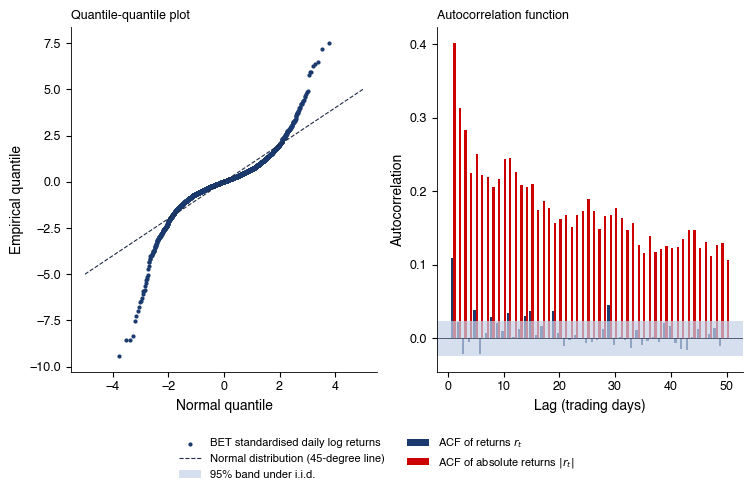

Hill tail index of losses: 2.39, block-bootstrap 95% CI [2.12, 3.03] (k = 153 largest losses)


,BET
Number of daily returns,6670
First day,2000-01-06
Last day,2026-09-18
Mean return (%),0.0639
Standard deviation (%),1.3986
Skewness,-0.6533
Excess kurtosis (descriptive only),11.0629
Minimum return (%),-13.1168
Date of the minimum,2009-01-07
Maximum return (%),10.5645


In [6]:
part_facts()
h = RES['facts']['hill']
print(f"Hill tail index of losses: {h['alpha']:.2f}, block-bootstrap 95% CI [{h['lo']:.2f}, {h['hi']:.2f}] (k = {h['k']} largest losses)")
labelled(RES['facts'], FACT_NAMES).to_frame('BET')

## Step 2. GARCH(1,1) with Student-t innovations

- Profile-likelihood CI for the persistence $p = \alpha + \beta$ on the parameter space $p \le 1$; at $p = 1$ (integrated GARCH, IGARCH) the likelihood-ratio statistic is compared with 2.71, the 5% critical value of its boundary distribution $\frac{1}{2}\chi^2_0 + \frac{1}{2}\chi^2_1$.

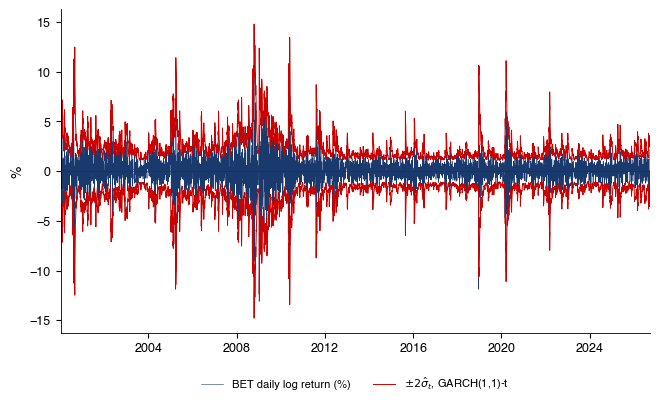

Persistence alpha + beta: 0.9907; profile-likelihood 95% CI: [0.975, 1.000]
Half-life at the lower bound: 27 days (no finite upper bound when the CI reaches 1)
LR statistic at p = 1 (IGARCH): 1.01, p-value 0.157 (5% critical value 2.71)


,BET
Mean mu (%),0.0832
omega,0.0448
alpha,0.1916
beta,0.7991
Degrees of freedom nu,5.0112
Robust standard error of alpha,0.0246
Robust standard error of beta,0.0237
Robust standard error of nu,0.3084
Persistence alpha + beta,0.9907
Half-life (days),74.2777


In [7]:
full = part_garch()
profile_view(RES['garch']['profile'])
labelled(RES['garch'], GARCH_NAMES).to_frame('BET')

## Steps 3–4. One-day VaR 1% and backtesting, 2005–2026

- Forecast for day $t$ uses data up to $t-1$; GARCH re-estimated every 21 days on the last 1000 days.

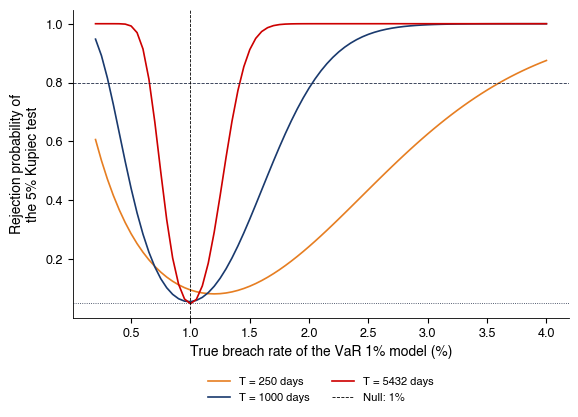

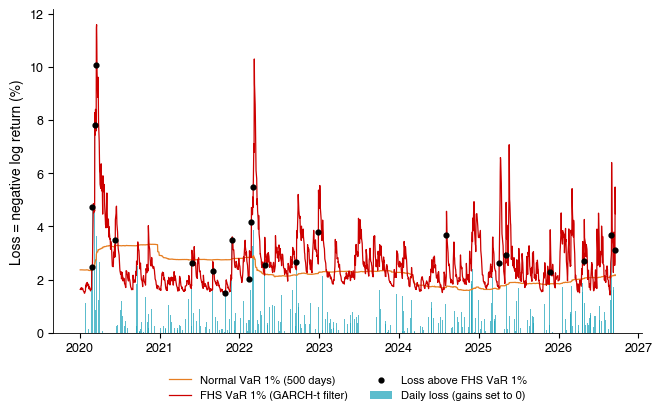

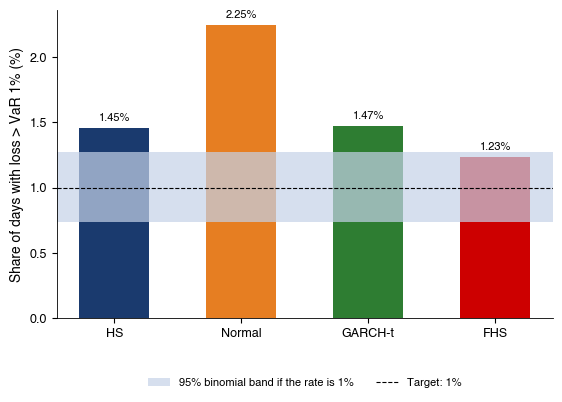

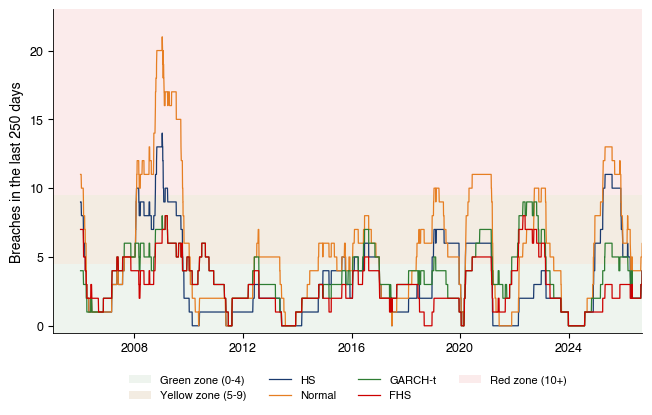

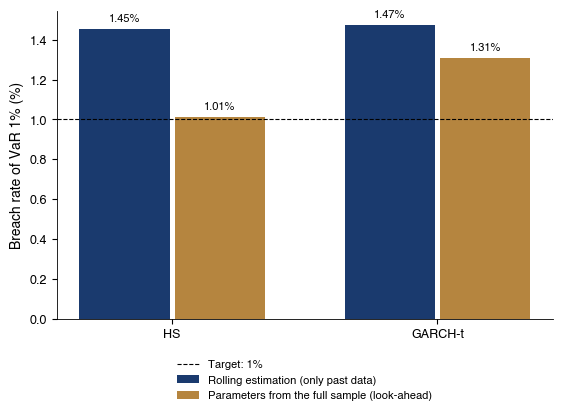

,Breaches,Breach rate,Kupiec p-value,Christoffersen independence p-value,Joint coverage p-value,Share of 250-day windows in the Basel red zone,Mean VaR 1% (%)
HS,79.0,0.0145,0.0016,0.0000,0.0000,0.0546,3.6638
Normal,122.0,0.0225,0.0000,0.0000,0.0000,0.1862,2.9039
GARCH-t,80.0,0.0147,0.0011,0.8641,0.0047,0.0000,2.9512
FHS,67.0,0.0123,0.0953,0.2674,0.1345,0.0000,3.1704


In [8]:
part_var(full)
backtest_view(RES['backtest'], ['x', 'rate', 'p_uc', 'p_ind', 'p_cc', 'share_red', 'mean_var'])

## The look-ahead trap

- Parameters estimated on the full sample give breach rates that no forecaster could have achieved in real time.

In [9]:
LA = RES['lookahead']
print(f"GARCH-t with full-sample parameters: {LA['garch_full_x']} breaches, rate {LA['garch_full_rate']:.2%}, Kupiec p-value {fmt_p(LA['garch_full_p'])}")
print(f"HS with the full-sample 99% quantile ({LA['hs_full_var']:.2f}%): {LA['hs_full_x']} breaches, rate {LA['hs_full_rate']:.2%}")

GARCH-t with full-sample parameters: 71 breaches, rate 1.31%, Kupiec p-value 0.030
HS with the full-sample 99% quantile (4.24%): 55 breaches, rate 1.01%


## Step 5. Comparing the four models formally

- DQ test, FZ0 scores for (VaR 2.5%, ES 2.5%) with Diebold–Mariano tests, the model confidence set, a comparative ES backtest, and the power of Kupiec.

In [10]:
F = RES['formal']
print(pd.DataFrame({'DQ p-value': {m: F['dq'][m]['p'] for m in F['dq']}, 'Mean FZ0 score': F['fz0'], 'MCS p-value': F['mcs_p']}).round(4))
print('Model confidence set (10%):', ', '.join(F['mcs_set']))
print('ES zones of the comparative backtest:', ', '.join(f"{m}: {v['zone']}" for m, v in F['cb'].items()))
P = RES['power']
print(f"Power of the 5% Kupiec test against a true breach rate of 2% at T = 250: {P['pw']['250_0.02']:.0%}")
print('Smallest breach rate detected with 80% power:', ', '.join(f'T = {T}: {v:.2%}' for T, v in P['mde'].items()))

         DQ p-value  Mean FZ0 score  MCS p-value
HS           0.0000          1.4235       0.0000
Normal       0.0000          1.4950       0.0000
GARCH-t      0.0066          1.1751       0.1792
FHS          0.1291          1.1574       1.0000
Model confidence set (10%): GARCH-t, FHS
ES zones of the comparative backtest: Normal: red, GARCH-t: green, FHS: green
Power of the 5% Kupiec test against a true breach rate of 2% at T = 250: 24%
Smallest breach rate detected with 80% power: T = 250: 3.65%, T = 1000: 2.05%, T = 5432: 1.45%


## Your turn

- Replace `'bet'` with another series from the dictionary `MARKETS` defined in the Data section (for example `'sp500'` or `'btc'`) and rerun the four steps.
- Which model passes both the Kupiec coverage test and the Christoffersen independence test on your series?